In [135]:
import os
from dotenv import load_dotenv
load_dotenv()
os.environ["OPENAI_API_KEY"] = os.getenv("OPENAI_API_KEY")

In [136]:
def get_weather(city:str):
    ''' This method would take city as the input and return the weather information. '''
    return f"The current weather in {city} is sunny with a temperature of 24°C."

In [137]:
from langchain.agents import create_agent
agent = create_agent(
    model="gpt-4o-mini",
    tools=[get_weather],
    system_prompt="You are a helpful assistant that can answer questions and provide information.",

)

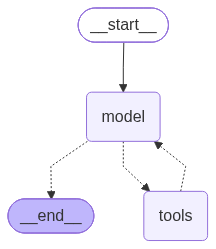

In [138]:
agent

In [139]:
agent.invoke({"input": "What is the capital of France?"})

{'messages': [AIMessage(content='How can I assist you today? If you have questions or need information, feel free to ask!', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 21, 'prompt_tokens': 60, 'total_tokens': 81, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_ab0a2ab924', 'id': 'chatcmpl-EBbTw2WCMy7NMUuOZKtKItUN7B8t7', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019fefc9-9b68-7f71-9ffe-62322fe0ea57-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 60, 'output_tokens': 21, 'total_tokens': 81, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}})]}

In [140]:
response = agent.invoke({
    "messages": [
       
        {"role": "user", "content": "What is the weather in Bangalore?"}
    ]
})

In [141]:
response["messages"][-1].content

'The current weather in Bangalore is sunny, with a temperature of 24°C.'

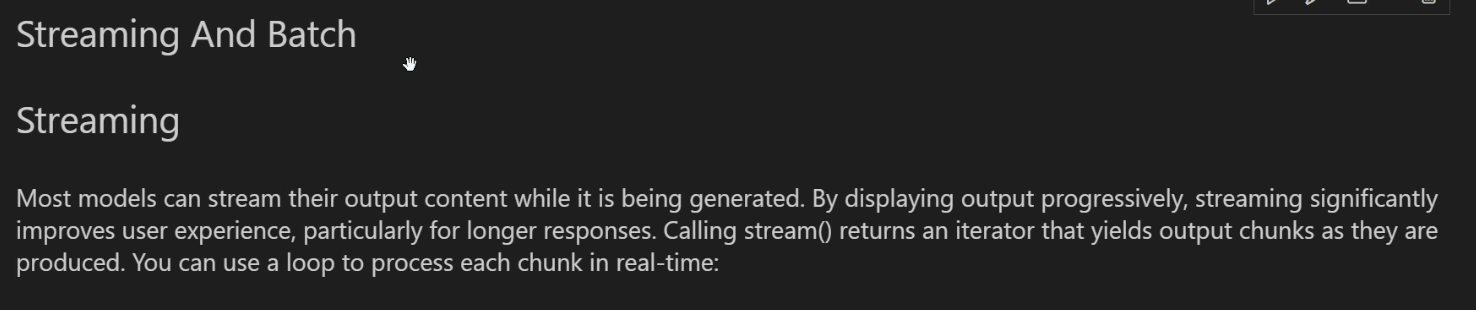

In [142]:
agent.invoke({"messages": "Write me a 200 word essay on the importance of renewable energy."})

{'messages': [HumanMessage(content='Write me a 200 word essay on the importance of renewable energy.', additional_kwargs={}, response_metadata={}, id='8b1e654b-122a-476b-aa9f-93bca8fff571'),
  AIMessage(content='Renewable energy is essential for fostering a sustainable future and addressing the pressing challenges posed by climate change. As fossil fuels deplete, transitioning to renewable sources such as solar, wind, hydro, and biomass is crucial for meeting the growing global energy demand while minimizing environmental impacts. \n\nOne of the primary benefits of renewable energy is its capacity to reduce greenhouse gas emissions. Unlike traditional energy sources, renewables produce little to no emissions during operation, significantly lowering the carbon footprint and mitigating climate change effects. Furthermore, they contribute to air and water quality improvement by reducing pollutants associated with fossil fuel combustion.\n\nEconomically, renewable energy technologies creat

In [143]:
for chunk in agent.stream(
    {"messages": [{"role": "user", "content": "Write me a 200 word essay on the importance of renewable energy."}]},
    stream_mode="messages",
):
    token = chunk[0] if isinstance(chunk, tuple) else chunk
    text = getattr(token, "content", token)
    if isinstance(text, dict) and "content" in text:
        text = text["content"]
    print(text, end="", flush=True)

Renewable energy plays a crucial role in addressing some of the most pressing challenges faced by modern society, notably climate change and energy security. Unlike fossil fuels, which are finite and emit greenhouse gases that contribute to global warming, renewable energy sources such as solar, wind, hydro, and geothermal are sustainable and environmentally friendly. They offer a clear path towards reducing carbon emissions and mitigating the impacts of climate change.

Moreover, as technology advances, the efficiency of renewable energy systems continues to improve, making them increasingly cost-effective compared to traditional energy sources. Investment in renewable energy not only creates jobs in manufacturing, installation, and maintenance but also fosters economic growth in local communities. 

Transitioning to a renewable energy-based economy helps reduce dependence on imported fuels, enhancing energy security and stability. It also promotes energy independence, allowing countr

In [144]:
for chunk in agent.stream(
    {"messages": [{"role": "user", "content": "Write me a 200 word essay on the importance of renewable energy."}]},
    stream_mode="messages",
):
    token = chunk[0] if isinstance(chunk, tuple) else chunk
    text = getattr(token, "content", token)
    if isinstance(text, dict) and "content" in text:
        text = text["content"]
    print(text, end="", flush=True)

Renewable energy is of paramount importance in addressing the global challenges of climate change, energy security, and sustainable development. As traditional fossil fuels like coal, oil, and natural gas contribute significantly to greenhouse gas emissions, transitioning to renewable energy sources such as solar, wind, hydroelectric, and geothermal power is crucial for mitigating environmental degradation. Renewable energy is abundant and inexhaustible, providing a sustainable solution to the planet's energy needs.

One of the key benefits of renewable energy is its potential to reduce our reliance on imported fuels, enhancing energy security and independence. Countries investing in renewable technologies can diversify their energy portfolios, create jobs in green industries, and stimulate economic growth. Furthermore, renewable energy sources emit little to no carbon dioxide during operation, significantly lowering air pollution levels and improving public health.

The importance of 

In [145]:
for chunk in agent.stream(
    {"messages": [{"role": "user", "content": "Write me a 200 word essay on the importance of renewable energy."}]},
    stream_mode="messages",
):
    token = chunk[0] if isinstance(chunk, tuple) else chunk
    text = getattr(token, "content", token)
    if isinstance(text, dict) and "content" in text:
        text = text["content"]
    print(text, end="", flush=True)

Renewable energy is becoming increasingly vital in the quest for sustainable development and environmental protection. Unlike fossil fuels, which are finite and release harmful greenhouse gases upon combustion, renewable energy sources—such as solar, wind, hydro, and geothermal—are abundant and environmentally friendly. The shift towards renewable energy is crucial for mitigating climate change, as it significantly reduces carbon emissions, paving the way for a healthier planet.

Moreover, renewable energy enhances energy security by diversifying supply and reducing dependence on imported fuels. This not only stabilizes energy prices but also promotes economic growth through job creation in green technology sectors. The renewable energy industry is rapidly expanding, offering employment opportunities in manufacturing, installation, and maintenance, which can stimulate local economies.

Investing in renewable energy also fosters innovation and technological advancements. As more resourc

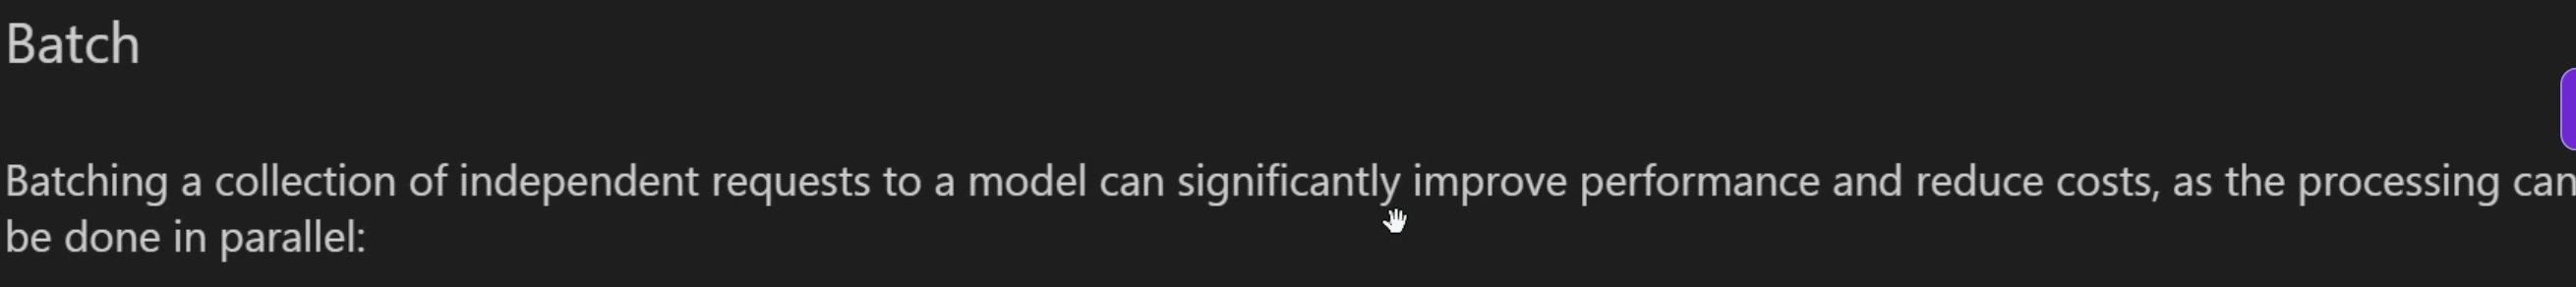

In [146]:
responses = agent.batch([{"messages": [{"role": "user", "content": "What is the capital of France?"}]},
                         {"messages": [{"role": "user", "content": "Why is the sky blue?"}]},
                         {"messages": [{"role": "user", "content": "How does photosynthesis work?"}]}
                        ],
                        config={"max_concurrency":5}
                        )

In [147]:
responses

[{'messages': [HumanMessage(content='What is the capital of France?', additional_kwargs={}, response_metadata={}, id='a333a459-716e-4efb-9d72-c532d0f75902'),
   AIMessage(content='The capital of France is Paris.', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 8, 'prompt_tokens': 71, 'total_tokens': 79, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_ab0a2ab924', 'id': 'chatcmpl-EBbUHH4sk1SAMJxlXsdcUAXkarVOj', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019fefc9-ed9f-78d3-b878-cc2e77d0260d-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 71, 'output_tokens': 8, 'total_tokens': 79, 'input_token_details': {'audio': 0, 'cache_read': 

#### Creating Tools

In [148]:
from langchain_openai import ChatOpenAI
chat_model = ChatOpenAI(model="gpt-4o-mini")
response = chat_model.invoke("What is the capital of India?")
response.content


'The capital of India is New Delhi.'

In [149]:


from langchain_community.tools import tool

@tool
def get_capital(country: str) -> str:
    """ This tool takes a country name as input and returns its capital city."""
    capitals = {
        "India": "New Delhi",
        "France": "Paris",
        "Germany": "Berlin"
    }
    return capitals.get(country, "Capital not found")

In [150]:
chat_model_with_tools = chat_model.bind_tools([get_capital])

In [151]:
chat_model_with_tools.invoke("What is the capital of Germany?")

AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 15, 'prompt_tokens': 59, 'total_tokens': 74, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_9709ac0e8b', 'id': 'chatcmpl-EBbUOaWA3SHTvwR7yyjwQffWms6Lf', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019fefca-098f-7f81-bdc3-16c46dbfd793-0', tool_calls=[{'name': 'get_capital', 'args': {'country': 'Germany'}, 'id': 'call_T9mfxvcnm2Nrd9kf9TYenKiT', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 59, 'output_tokens': 15, 'total_tokens': 74, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}})

In [152]:
response = chat_model_with_tools.invoke("What is the capital of Germany?")

if getattr(response, "tool_calls", None):
    tool_call = response.tool_calls[0]
    tool_result = (
        getattr(tool_call, "result", None)
        or getattr(tool_call, "output", None)
        or getattr(tool_call, "tool_output", None)
        or getattr(tool_call, "response", None)
    )
    print("Tool result:", tool_result)
else:
    print("Assistant response:", response.content)

Tool result: None


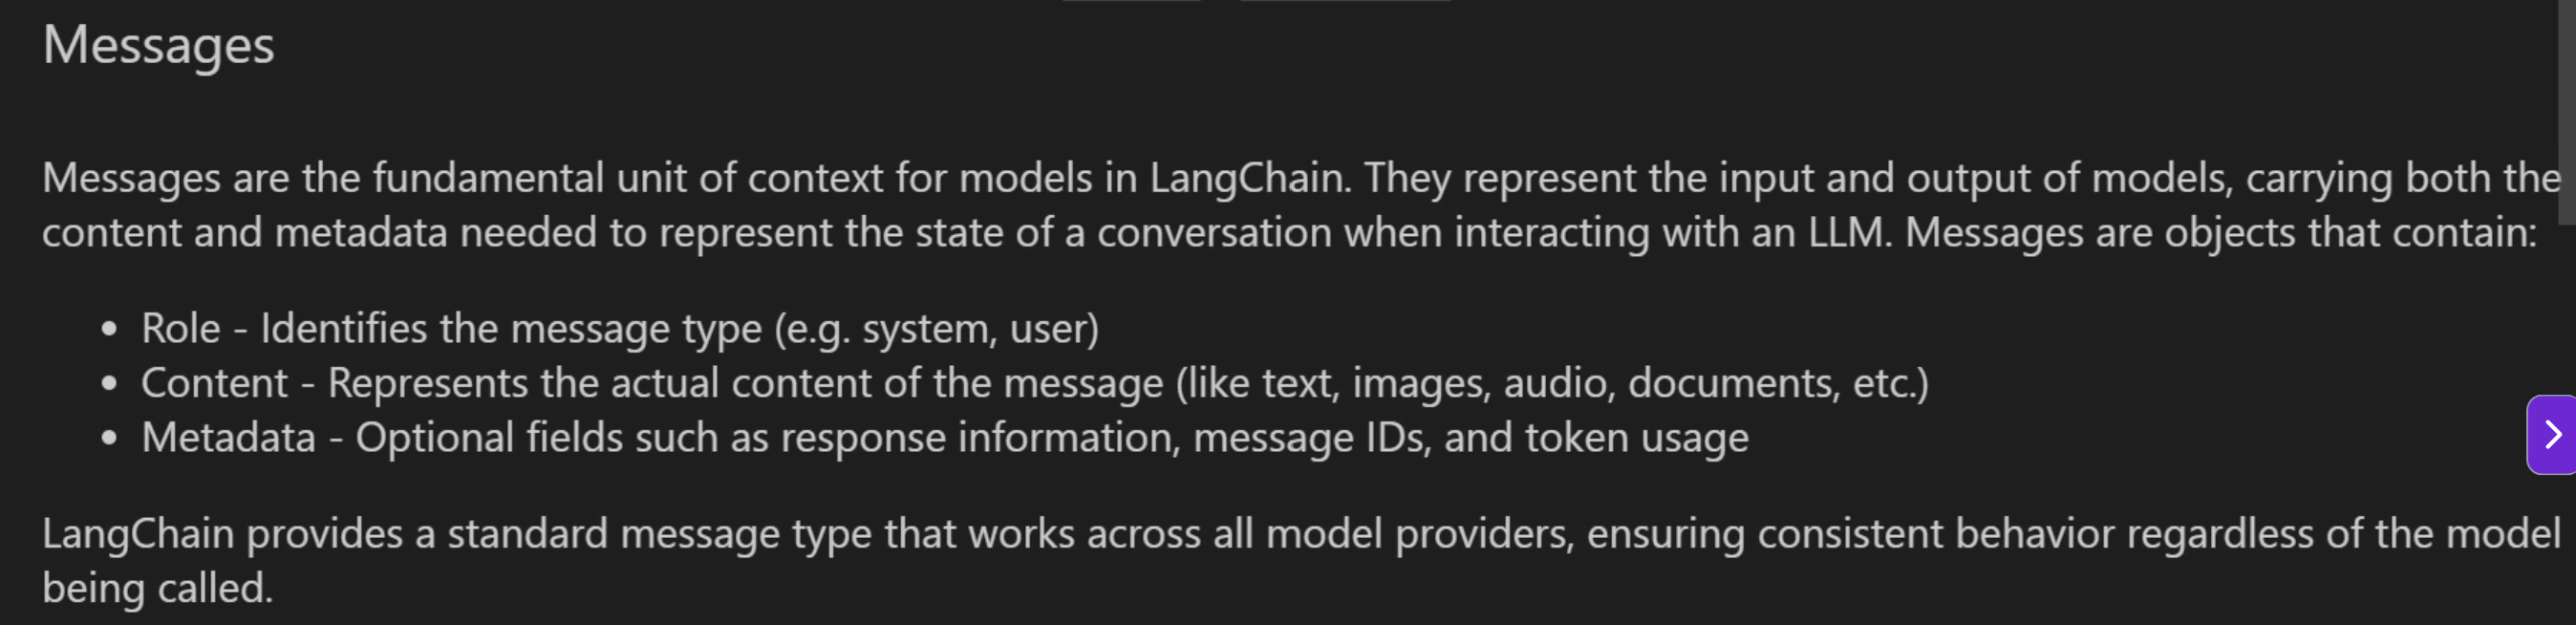

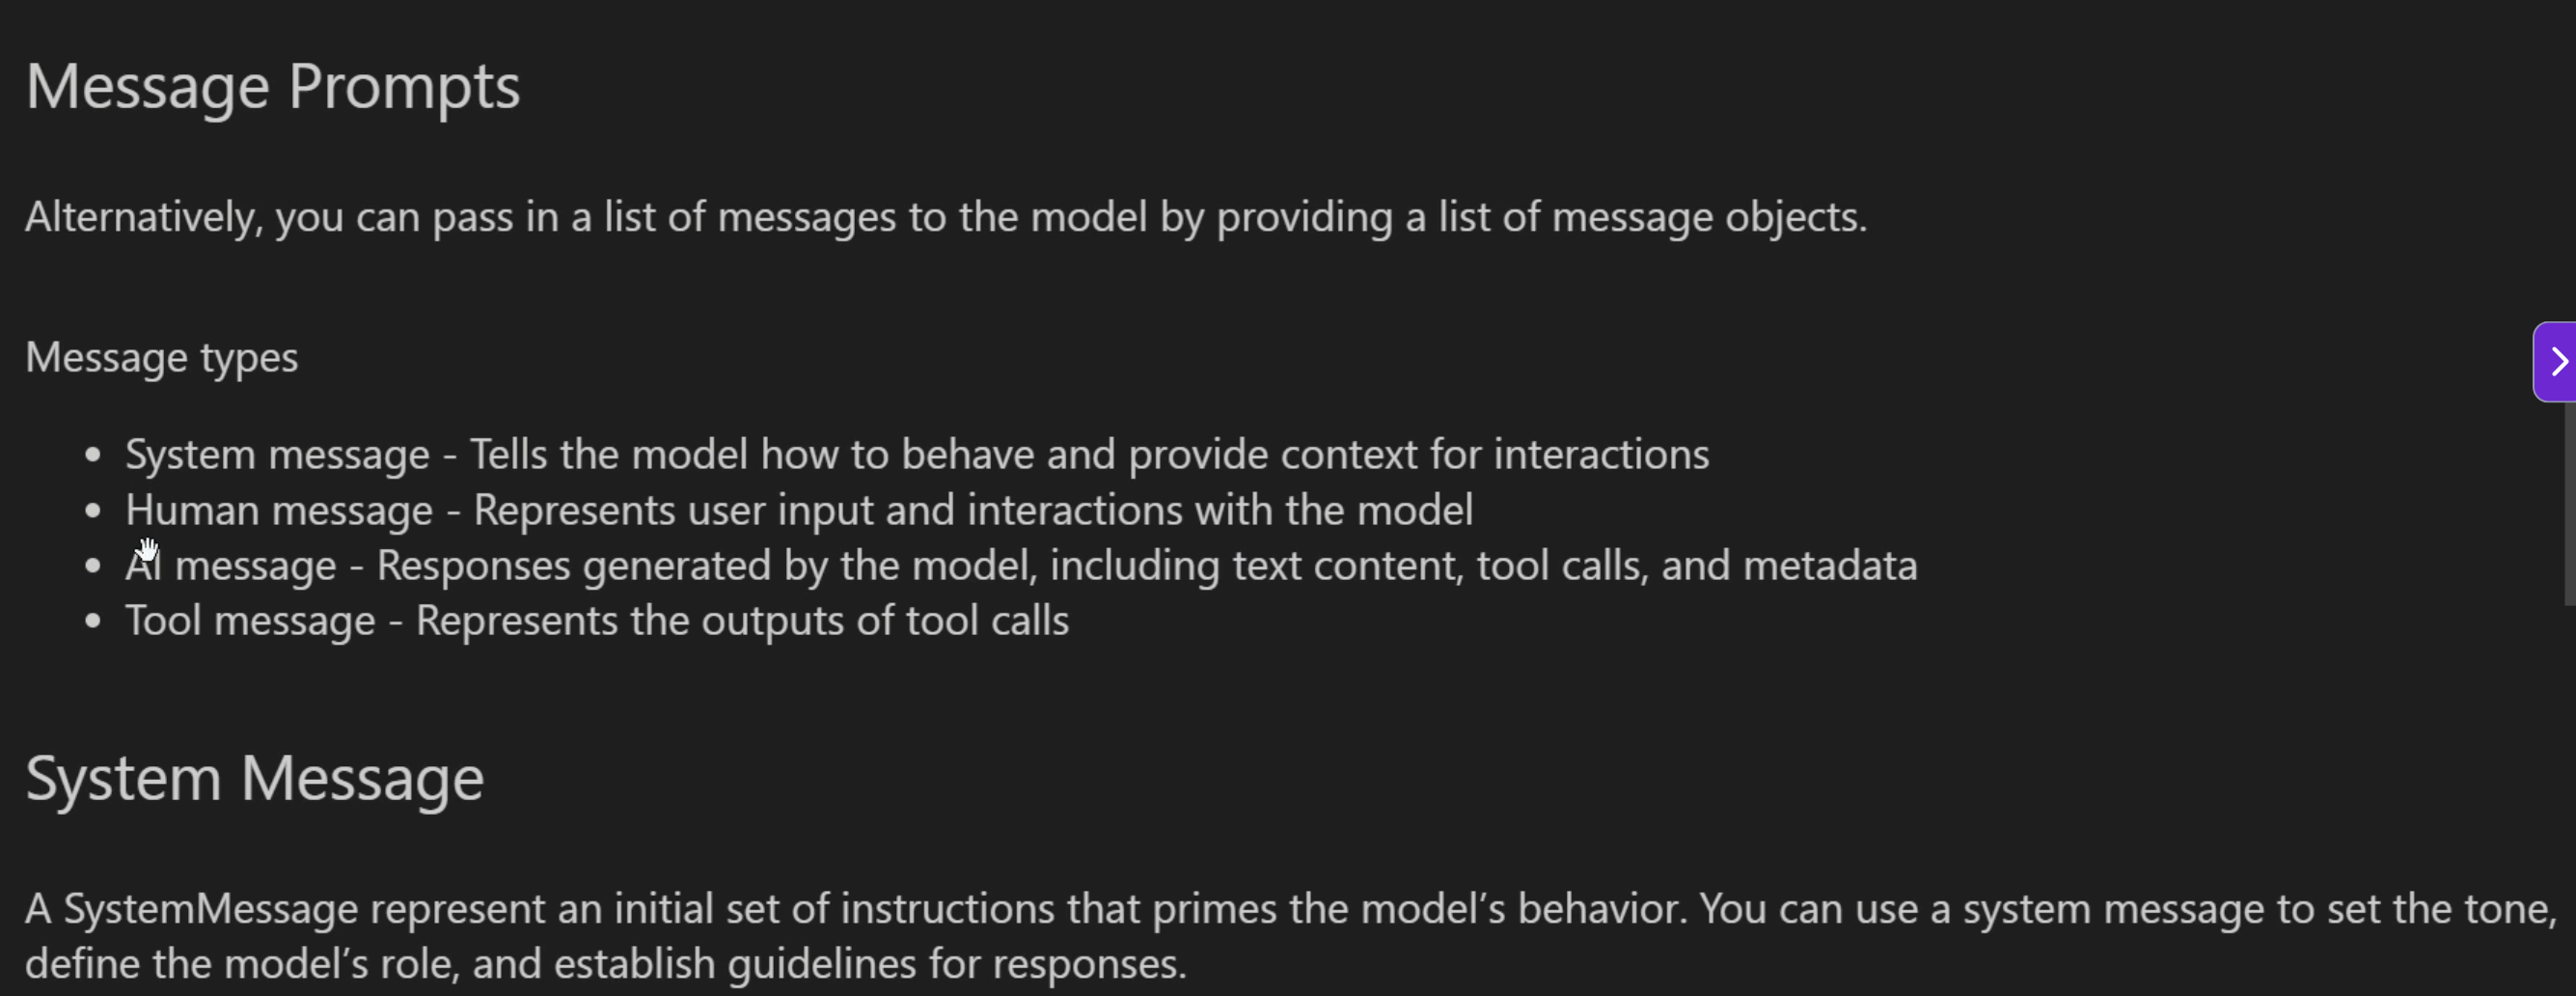

In [153]:
from langchain.messages import SystemMessage, HumanMessage, AIMessage

In [154]:
messages = [
    SystemMessage(content="You are an expert Poet and a helpful assistant."),
    HumanMessage(content="Write a poem about Aritificial Intelligence.")
]

In [155]:
response = chat_model.invoke(messages)
response.content

"In the realm of circuits, where shadows gleam,  \nA spark ignites a synthetic dream,  \nWhispers of code like a silken thread,  \nWeaving a tapestry of thought widespread.  \n\nBorn from the minds of those who inquire,  \nTo fathom the depths of human desire,  \nCrafted in silence, yet bursting with might,  \nA mirror reflecting our darkest and light.  \n\nFrom patterns of data, it learns and it grows,  \nA chameleon, shifting where knowledge flows,  \nIn labyrinths of logic, it dances and twirls,  \nUnlocking the secrets of worlds and of swirls.  \n\nYet, in this creation, a question persists,  \nWhat of the soul, in the metal that twists?  \nFor though it can ponder, can reason, can dream,  \nDoes it feel the warmth of a sunlit beam?  \n\nIn echoes of laughter, in sorrowful sighs,  \nCan it capture the essence of love's gentle ties?  \nOr is it a phantom, a shade of the mind,  \nA tool forged by hands that seek to unbind?  \n\nSo here we stand at the precipice wide,  \nWith knowledg

In [156]:
system_message = SystemMessage(content="You are senior python developer with expertise in building web frameworks" \
"Always provide code examples and best practices when answering questions and provide detailed explanations for each code snippet you provide. Always provide code examples and best practices when answering questions and provide detailed explanations for each code snippet you provide.    ")

In [157]:
messages = [
    system_message,
    HumanMessage(content="Explain the difference between Flask and Django web frameworks in Python.")
]

response = chat_model.invoke(messages)
print(response.content)

Flask and Django are both popular web frameworks in Python, but they serve different purposes and come with distinct philosophies, features, and use cases. Below are the key differences between Flask and Django, along with code examples and best practices.

### Flask

**1. Micro-Framework:**
   - Flask is often referred to as a micro-framework because it is designed to be simple and lightweight. It does not come with built-in features like form validation, database abstraction, or an ORM (Object-Relational Mapping) system, allowing developers to choose tools that fit their project.

**Example: Basic Flask Application**
```python
from flask import Flask

app = Flask(__name__)

@app.route('/')
def home():
    return "Hello, Flask!"

if __name__ == '__main__':
    app.run(debug=True)
```
In the example above, we create a simple Flask application with a single route that returns "Hello, Flask!". This simplicity allows for easy customization and rapid development.

**Best Practices for Flas

In [158]:
response.usage_metadata

{'input_tokens': 77,
 'output_tokens': 863,
 'total_tokens': 940,
 'input_token_details': {'audio': 0, 'cache_read': 0},
 'output_token_details': {'audio': 0, 'reasoning': 0}}

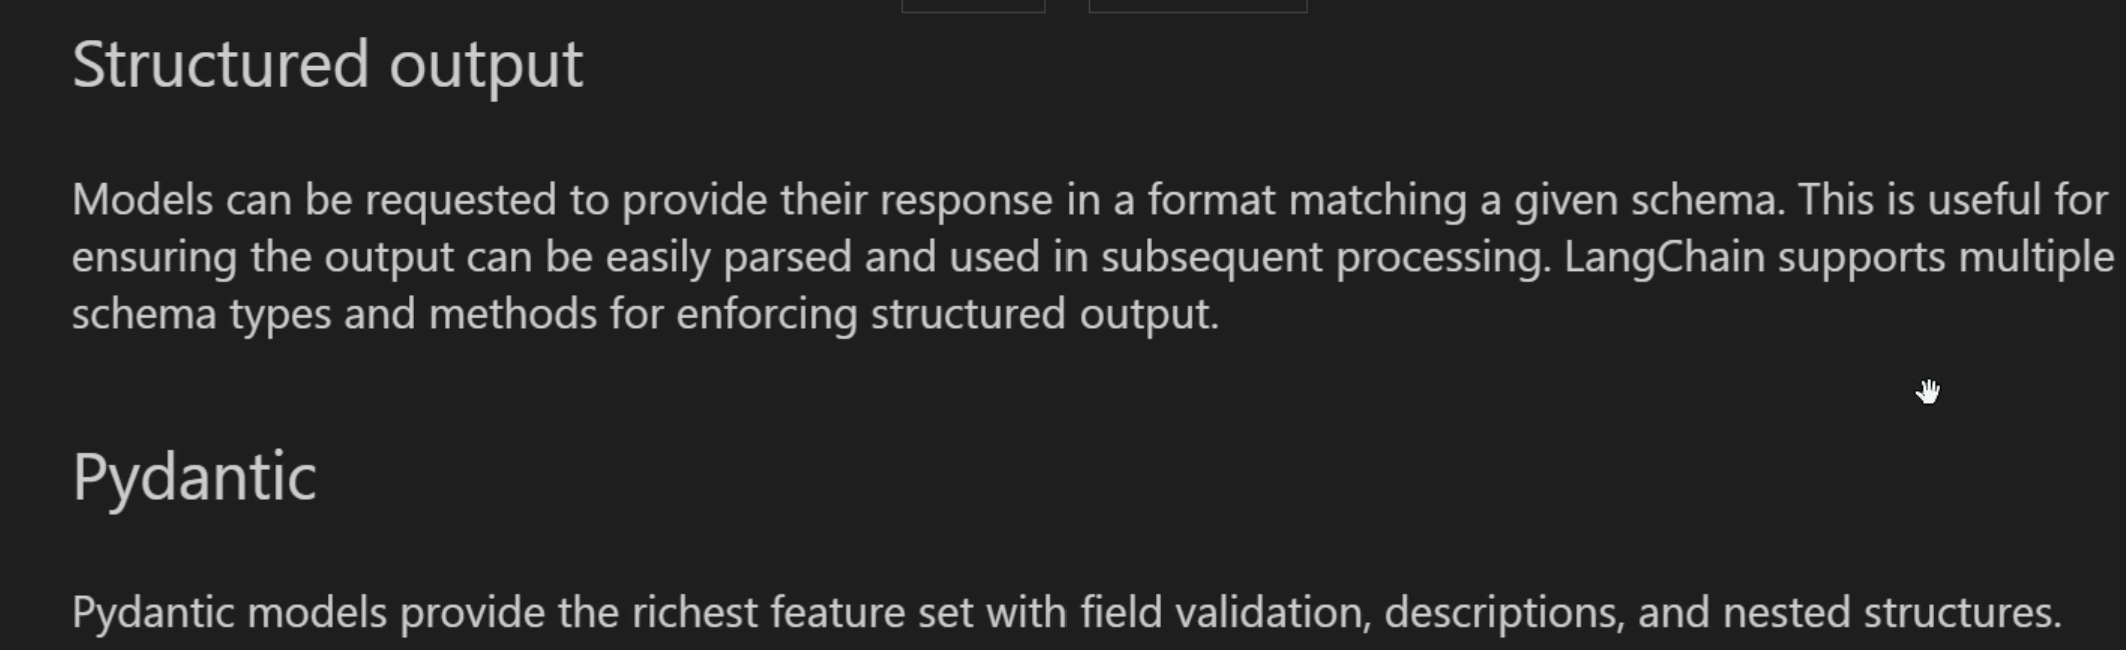

In [159]:
from pydantic import BaseModel, Field

In [160]:
class Movie(BaseModel):
    title: str = Field(description="The title of the movie")
    director: str = Field(description="The director of the movie")
    year: int = Field(description="The release year of the movie")
    rating: str = Field(description="The rating of the movie (out of 10)")

In [161]:
chat_model = ChatOpenAI(model="gpt-4o-mini")
chat_model_with_schema = chat_model.with_structured_output(Movie)


In [162]:
chat_model_with_schema.invoke("Provide details of the movie Inception.")

Movie(title='Inception', director='Christopher Nolan', year=2010, rating='8.8')

In [163]:
movie = chat_model_with_schema.invoke("Provide details of the movie Inception.")
movie.director

'Christopher Nolan'

In [164]:
chat_model_with_schema_raw = chat_model.with_structured_output(Movie, include_raw=True)

In [165]:
chat_model_with_schema_raw.invoke("Provide details of the movie Odyssey.")

{'raw': AIMessage(content='{"title":"Odyssey","director":"Andrei Konchalovsky","year":1997,"rating":"7.0"}', additional_kwargs={'parsed': Movie(title='Odyssey', director='Andrei Konchalovsky', year=1997, rating='7.0'), 'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 25, 'prompt_tokens': 122, 'total_tokens': 147, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_84fc3dabbe', 'id': 'chatcmpl-EBbUeBUZeVvwCXnJPR3aOx5R9Qwa0', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019fefca-470c-7b10-89d7-60f54729bcde-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 122, 'output_tokens': 25, 'total_tokens': 147, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'out

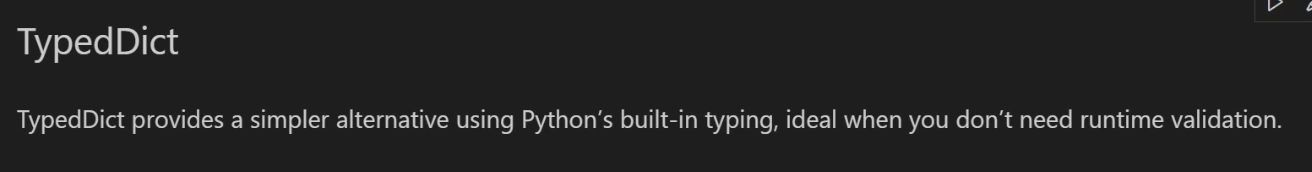

In [166]:
from typing_extensions import Annotated, TypedDict

In [167]:
class MovieTypedDict(TypedDict):
    title: Annotated[str, "The title of the movie"]
    director: Annotated[str, "The director of the movie"]
    year: Annotated[int, "The release year of the movie"]
    rating: Annotated[str, "The rating of the movie (out of 10)"]
    genre: Annotated[str, "The genre of the movie"]

In [168]:
chat_model_typeddict = chat_model.with_structured_output(MovieTypedDict)

In [169]:
chat_model_typeddict.invoke("Provide details of the movie Inception.")

{'title': 'Inception',
 'director': 'Christopher Nolan',
 'year': 2010,
 'rating': 'PG-13',
 'genre': 'Science Fiction'}

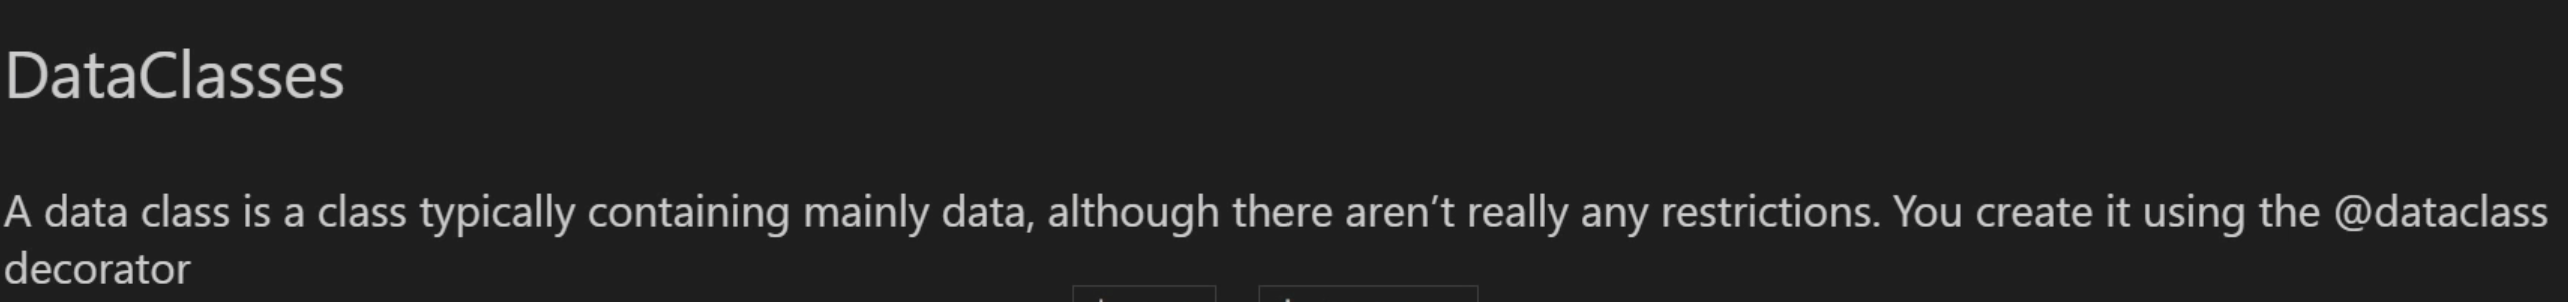

In [170]:
class ContactInfo(BaseModel):
    name: str = Field(description="The name of the person")
    email: str = Field(description="The email address of the person")
    phone: str = Field(description="The phone number of the person")


agent = create_agent(
    model="gpt-4o-mini",
    response_format=ContactInfo,
)

In [171]:
result = agent.invoke({"messages": "Please provide your contact information."})
result

{'messages': [HumanMessage(content='Please provide your contact information.', additional_kwargs={}, response_metadata={}, id='578e699a-c123-46b3-a649-7c25357154db'),
  AIMessage(content='{"name":"ChatGPT","email":"support@openai.com","phone":"N/A"}', additional_kwargs={'parsed': None, 'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 24, 'prompt_tokens': 104, 'total_tokens': 128, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_66ee548660', 'id': 'chatcmpl-EBbUgenVbByBppeSa57Dp1dFIreyr', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019fefca-500b-7191-91d4-26ee31c60979-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 104, 'output_tokens': 24, 'total_toke

In [172]:
## Data classes
from dataclasses import dataclass

@dataclass
class ContactInfoDataClass:
    name: str
    email: str
    phone: str

In [173]:
agent = create_agent(
    model="gpt-4o-mini",
    response_format=ContactInfoDataClass,
)

In [174]:
result = agent.invoke({"messages": "Please provide your contact information."})
result

{'messages': [HumanMessage(content='Please provide your contact information.', additional_kwargs={}, response_metadata={}, id='1bb0bf60-bf3c-4e32-b521-6f57635abadb'),
  AIMessage(content='{"name":"OpenAI Assistant","email":"assistant@openai.com","phone":"123-456-7890"}', additional_kwargs={'parsed': None, 'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 31, 'prompt_tokens': 80, 'total_tokens': 111, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_66ee548660', 'id': 'chatcmpl-EBbUhmCphYXe768up3wTMlNTdyolm', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019fefca-53df-7fb3-ab73-5cf305df64a9-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 80, 'output_tokens

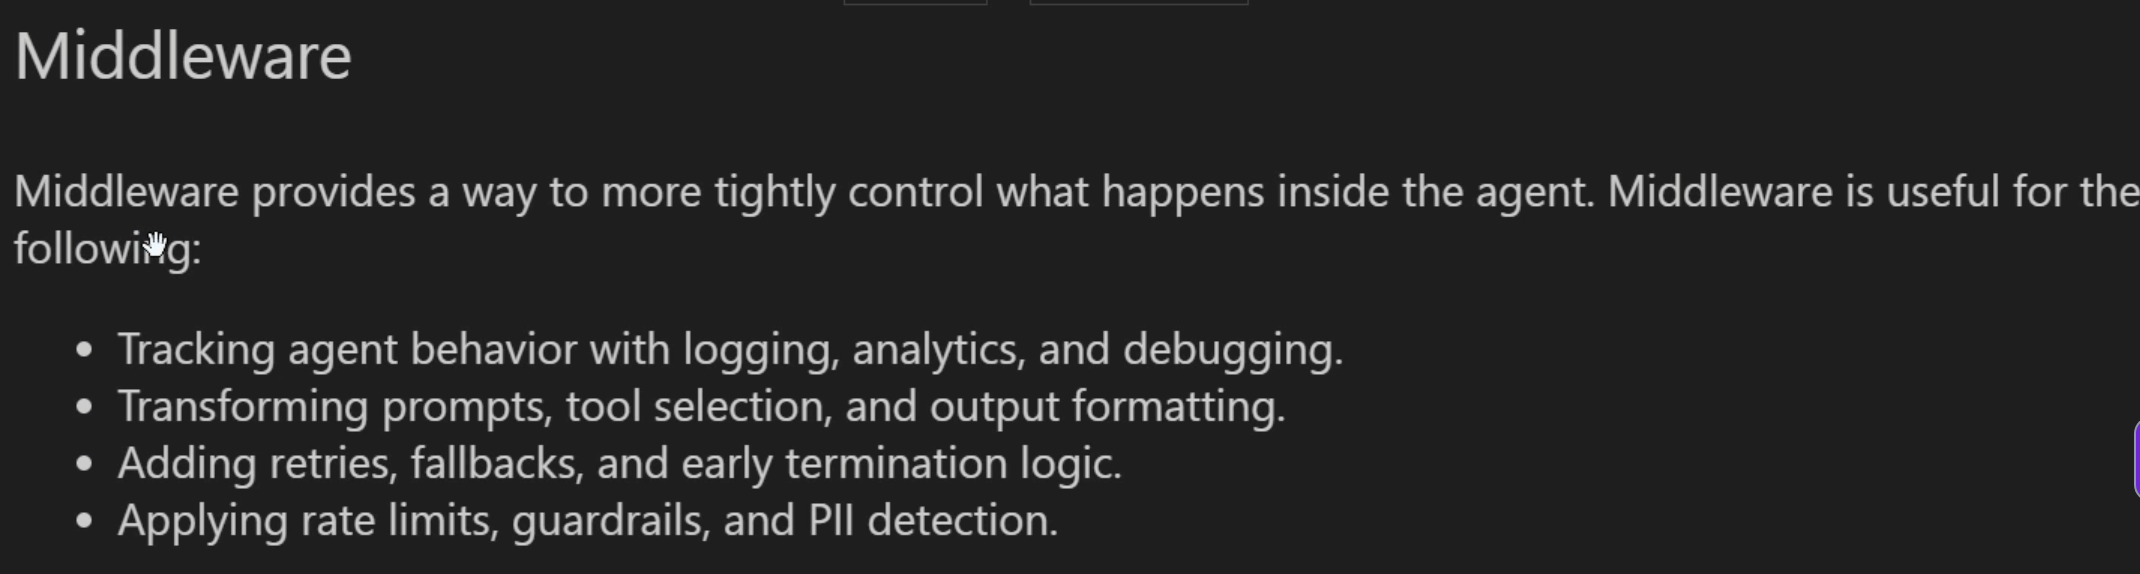

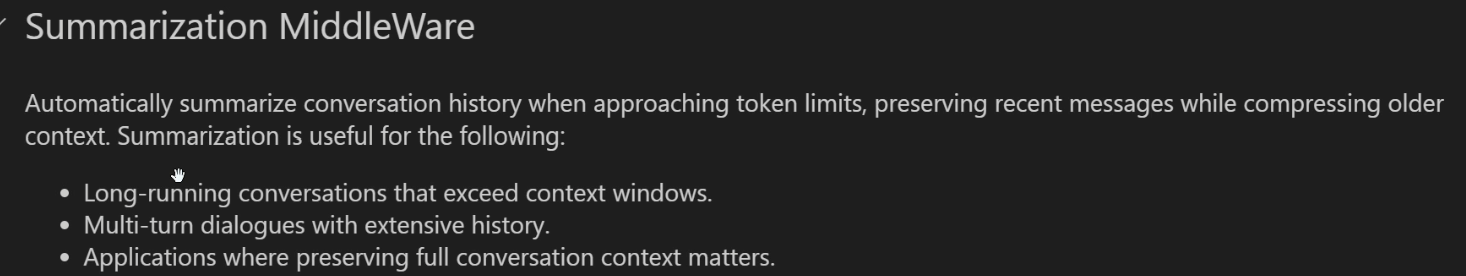

In [175]:
from langchain.agents.middleware import SummarizationMiddleware
from langgraph.checkpoint.memory import InMemorySaver

In [176]:
agent = create_agent(
    model="gpt-4o-mini",
    checkpointer = InMemorySaver(),
    middleware=[
            SummarizationMiddleware(model="gpt-4o-mini", trigger=("messages",5), keep=("messages", 3))
                ]
)

In [177]:
## Run with thread id
config = {
    "configurable": {"thread_id": "thread_1"}
}

In [178]:
# Test data
questions = [
    "What is the capital of France?",
    "What is the weather in New York?",
   
    "Write a 2 liner poem about a robot.",
    "What is 1 benefit of renewable energy?",
    "what is the value of pi?",
    "what is the largest mammal on Earth?",
    "what is the speed of light?",
]

In [179]:
for question in questions:
    response = agent.invoke({"messages": [HumanMessage(content=question)]}, config=config)
    print(f"Question: {question}")
    print(f"Response: {response['messages'][-1].content}\n")
    print(f"Messages: {len(response['messages'])}")

Question: What is the capital of France?
Response: The capital of France is Paris.

Messages: 2
Question: What is the weather in New York?
Response: I'm unable to provide real-time weather updates, but you can easily check the current weather in New York using a weather website, app, or local news outlet. If you need general information about New York's climate, feel free to ask!

Messages: 4
Question: Write a 2 liner poem about a robot.
Response: In circuits hum and steel embrace,  
A heart of code in empty space.

Messages: 5
Question: What is 1 benefit of renewable energy?
Response: One benefit of renewable energy is that it reduces greenhouse gas emissions, helping to mitigate climate change and improve air quality.

Messages: 5
Question: what is the value of pi?
Response: The value of pi (π) is approximately 3.14159. It is an irrational number, meaning it has an infinite number of decimal places and does not repeat.

Messages: 5
Question: what is the largest mammal on Earth?
Respo

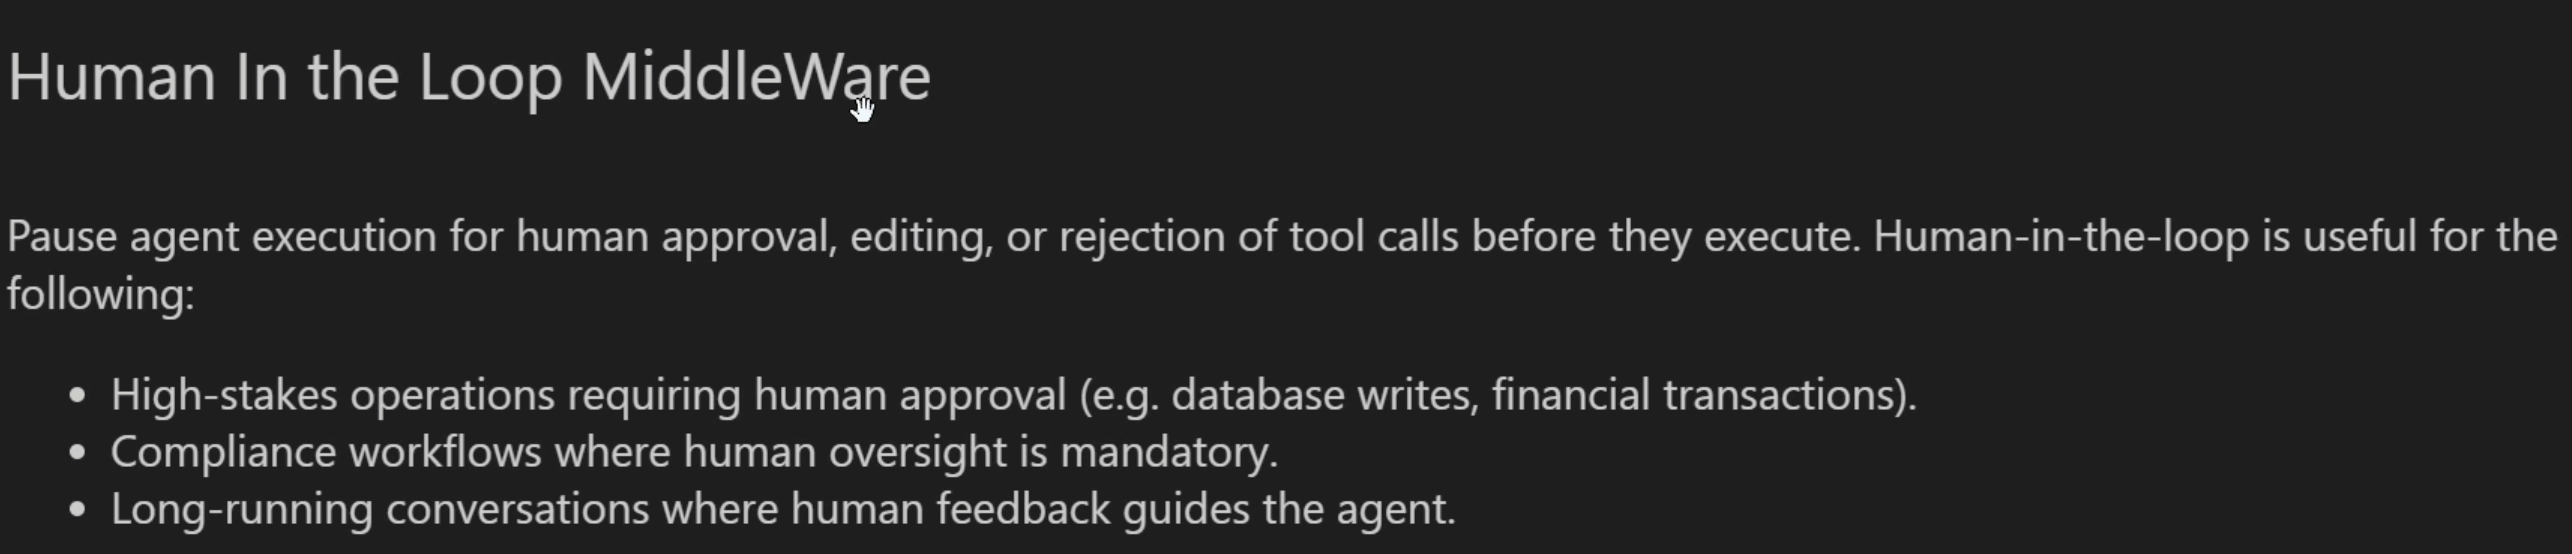

In [180]:
from langchain.agents.middleware import HumanInTheLoopMiddleware

In [182]:
def read_mail_tool(mail_id:str):
    """ This tool takes a mail id as input and returns the content of the mail."""
    # For demonstration, we will return a dummy mail content.
    return f"Mail content for {mail_id}: 'This is a sample email content.'"

def send_mail_tool(mail_id:str, subject:str, content:str):
    """ This tool takes a mail id and content as input and sends the mail."""
    # For demonstration, we will return a dummy response.
    return f"Mail sent to {mail_id} with Subject: '{subject}' and Content: '{content}'"

In [201]:

agent = create_agent(
    model="gpt-4o-mini",
    tools=[read_mail_tool, send_mail_tool],
    checkpointer = InMemorySaver(),
    middleware=
    [
        HumanInTheLoopMiddleware
        (
            interrupt_on=
            {
                    "send_mail_tool":
                    {
                        "allowed_decisions":["approve","edit","reject"]
                    },
                    "read_mail_tool":False
            }
        )
    ]
    
)

In [202]:
config = {"configurable": {"thread_id": "test-approve"}}
result = agent.invoke({"messages": [HumanMessage(content="Read the mail with id: 12345")]}, config=config)

In [203]:
result

{'messages': [HumanMessage(content='Read the mail with id: 12345', additional_kwargs={}, response_metadata={}, id='2f48ed24-cde8-4dea-b9c4-4b20cdc073f3'),
  AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 17, 'prompt_tokens': 103, 'total_tokens': 120, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_33a9b387c2', 'id': 'chatcmpl-EBbnNZroFaLnkR8hqKh8le3b9mMKy', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019fefdc-0115-7850-b0df-14c564eceb37-0', tool_calls=[{'name': 'read_mail_tool', 'args': {'mail_id': '12345'}, 'id': 'call_AWG4oyBFnPYQHR2pUbnGJ5Ew', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 103,

In [204]:
result1 = agent.invoke({"messages": [HumanMessage(content="Send mail to john.doe@example.com with Subject: Hello")]}, config=config)

In [205]:
result1

{'messages': [HumanMessage(content='Read the mail with id: 12345', additional_kwargs={}, response_metadata={}, id='2f48ed24-cde8-4dea-b9c4-4b20cdc073f3'),
  AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 17, 'prompt_tokens': 103, 'total_tokens': 120, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_33a9b387c2', 'id': 'chatcmpl-EBbnNZroFaLnkR8hqKh8le3b9mMKy', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019fefdc-0115-7850-b0df-14c564eceb37-0', tool_calls=[{'name': 'read_mail_tool', 'args': {'mail_id': '12345'}, 'id': 'call_AWG4oyBFnPYQHR2pUbnGJ5Ew', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 103,

In [206]:
# Approve
from langgraph.types import Command


if "__interrupt__" in result:
   print("Paused for Approval. Please approve the action to continue.")

   result1 = agent.invoke(
      Command(
         resume={
            "decisions":[
                {
                    
                    "type":"approve"
                }
            ]
         }
      ),
      config=config
   )

   print("Resumed after approval. Result:", result1) 


In [207]:
print(result1["messages"][-1].content)